Columns with object dtype:
- neighbourhood_group
- neighbourhood
- room_type
Processing pipeline steps manually...
Imputation done
Outlier handling done
Skewness handling done
Categorical encoding done
Numerical scaling done

Final column types in transformed training data:
- latitude: float64
- longitude: float64
- minimum_nights: float64
- number_of_reviews: float64
- reviews_per_month: float64
- calculated_host_listings_count: float64
- availability_365: float64
- neighbourhood_group_Bronx: float64
- neighbourhood_group_Brooklyn: float64
- neighbourhood_group_Manhattan: float64
- neighbourhood_group_Queens: float64
- neighbourhood_group_Staten Island: float64
- neighbourhood_Allerton: float64
- neighbourhood_Arrochar: float64
- neighbourhood_Arverne: float64
- neighbourhood_Astoria: float64
- neighbourhood_Battery Park City: float64
- neighbourhood_Bay Ridge: float64
- neighbourhood_Bay Terrace: float64
- neighbourhood_Baychester: float64
- neighbourhood_Bayside: float64
- neighbour

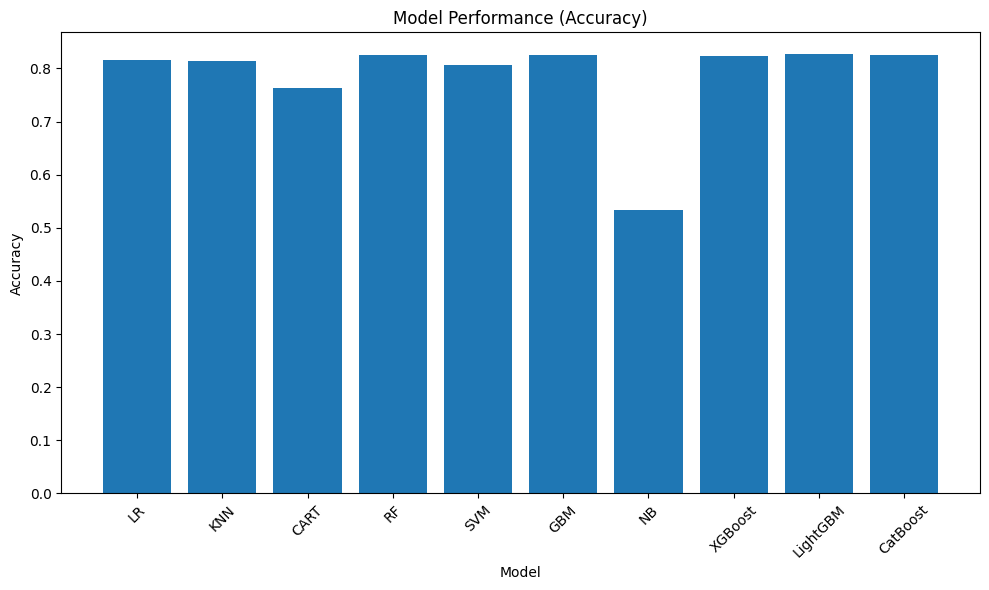

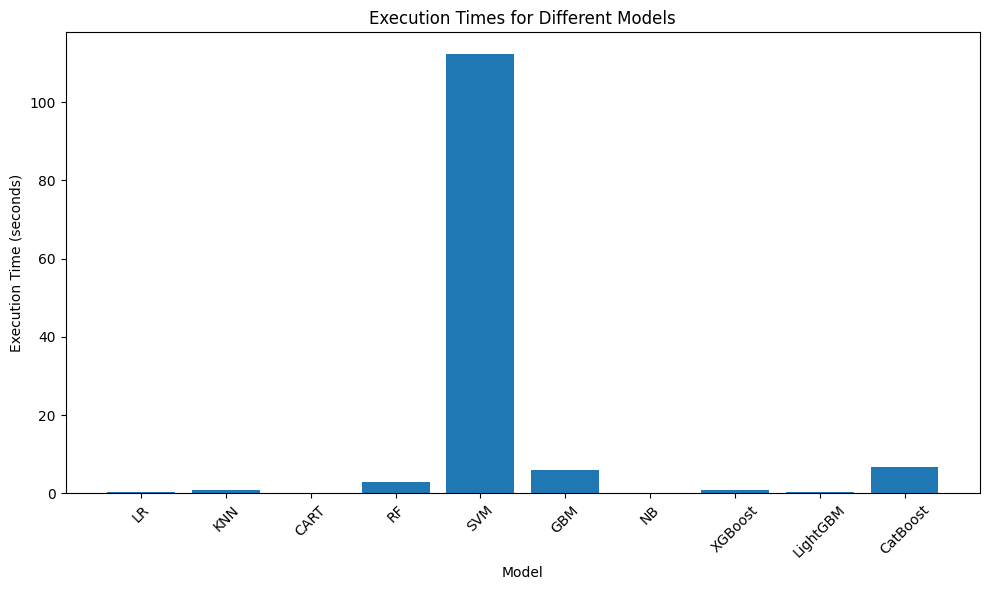

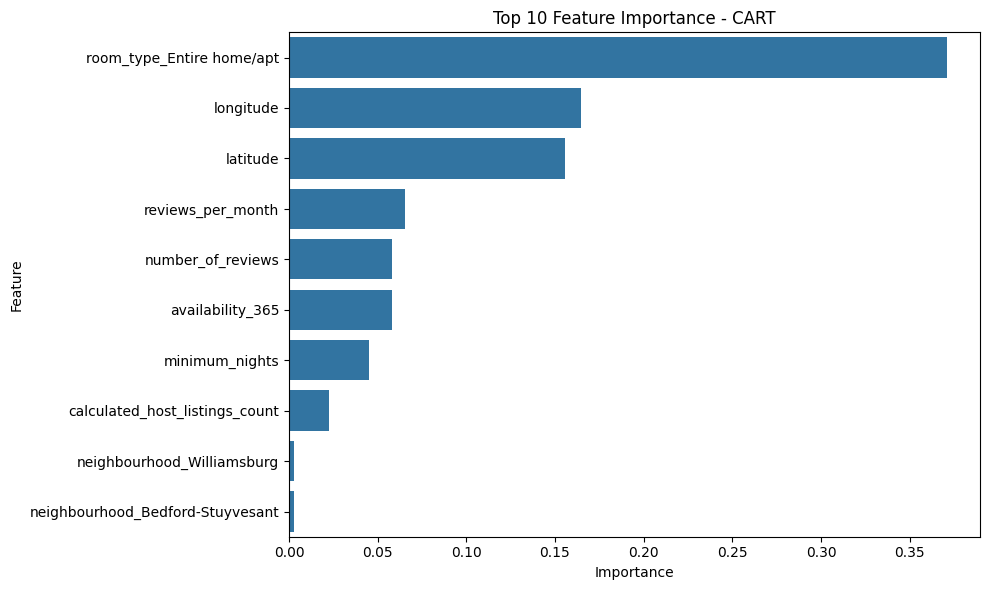

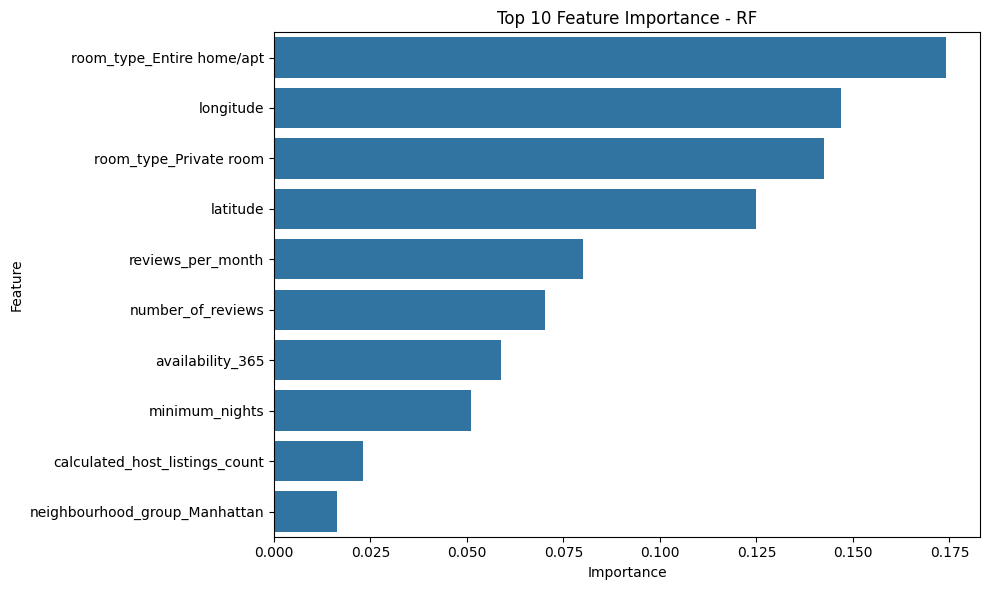

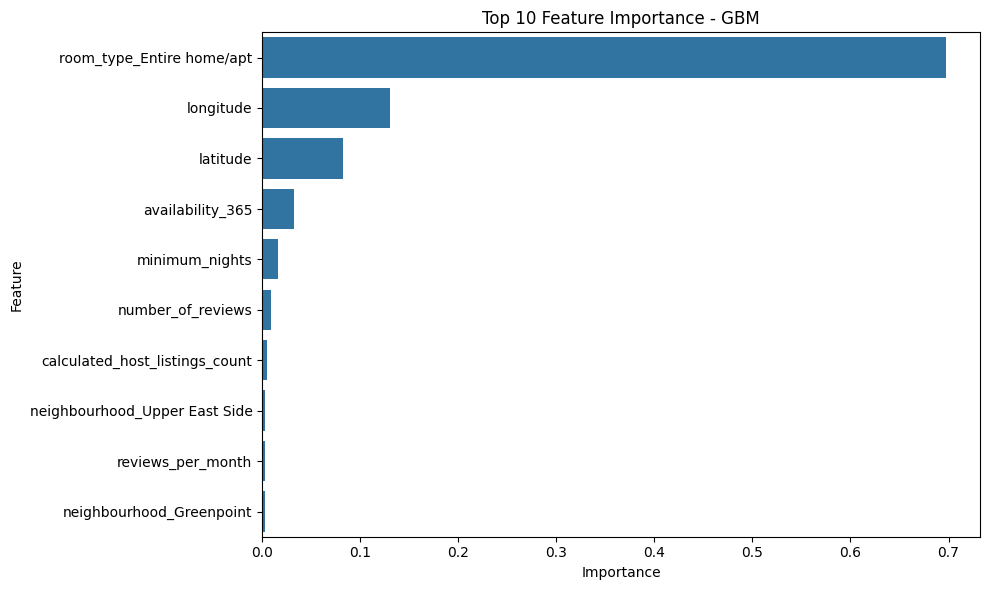

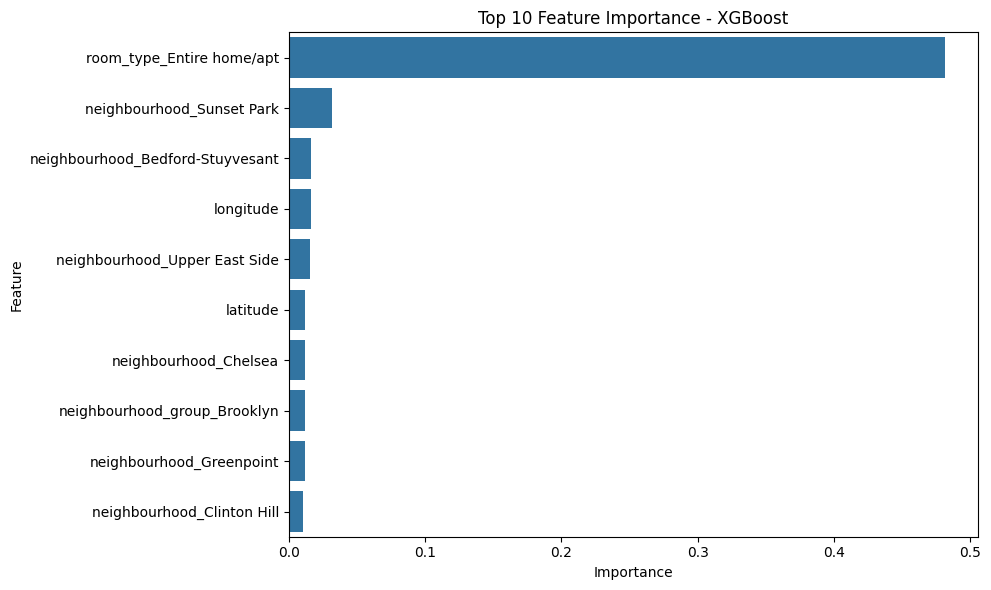

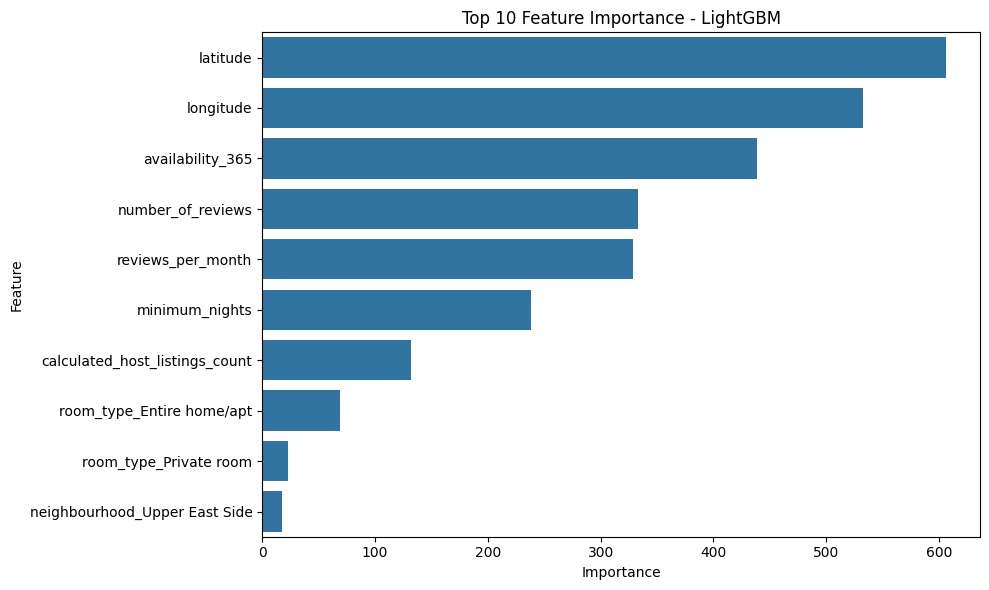

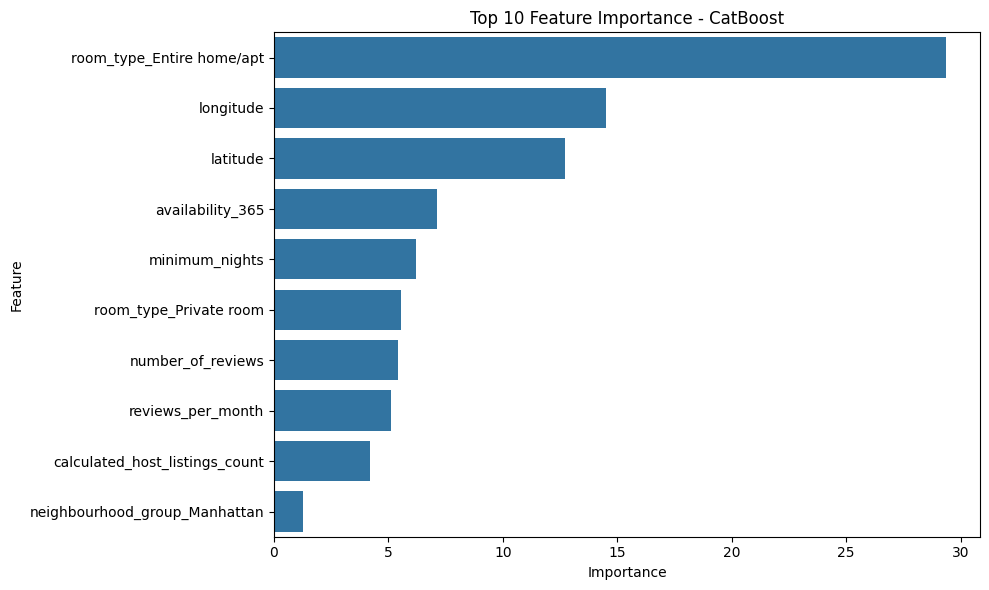


Preparing multi-class classification...

Running multi-class classification models...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.6496 (LR)
Execution Time: 1.2 seconds
Classification Report:
              precision    recall  f1-score   support

         0.0       0.75      0.78      0.77      1008
         1.0       0.54      0.46      0.50      1036
         2.0       0.64      0.71      0.68       933

    accuracy                           0.65      2977
   macro avg       0.64      0.65      0.65      2977
weighted avg       0.64      0.65      0.64      2977

Confusion Matrix:
[[790 186  32]
 [218 480 338]
 [ 44 225 664]]

--------------------------------------------------

Accuracy: 0.6271 (KNN)
Execution Time: 0.86 seconds
Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.76      0.74      1008
         1.0       0.50      0.47      0.49      1036
         2.0       0.66      0.66      0.66       933

    accuracy                           0.63      2977
   macro avg       0.62      0.63      0.63      2977
weighted avg       0.62     

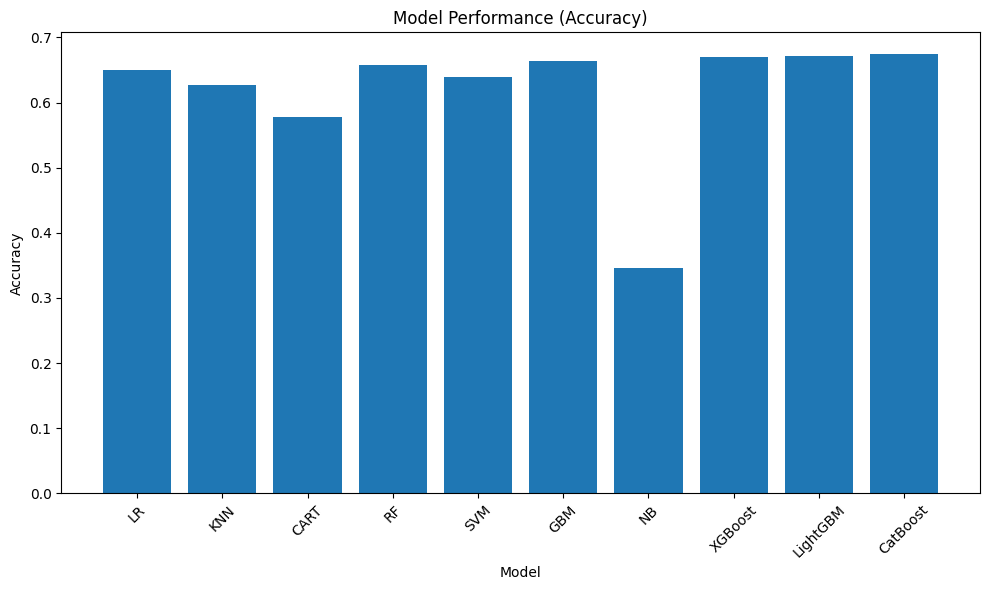

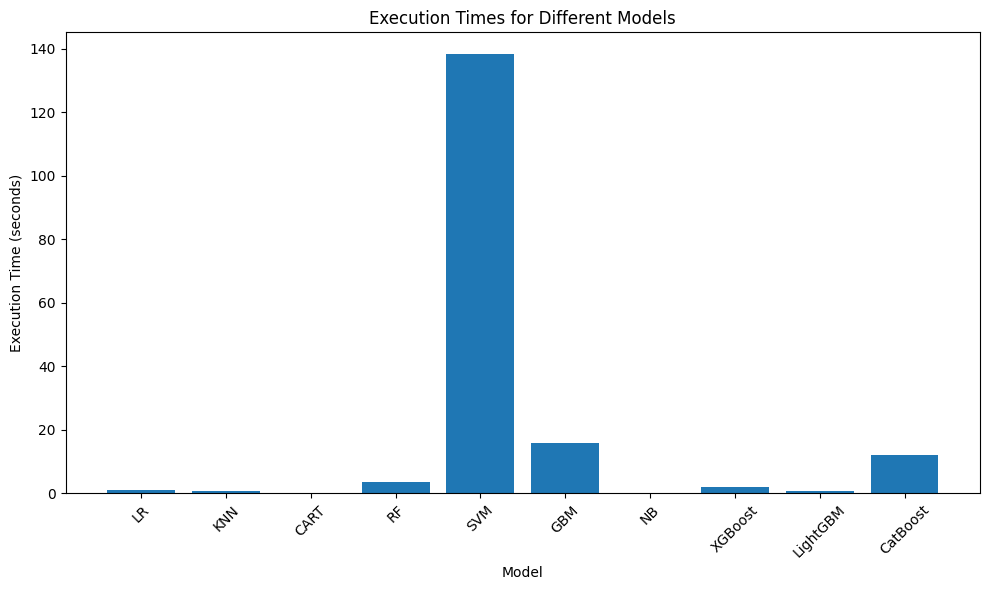

In [ ]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer


# Add all the preprocessing classes that were in your original code
class DataAnalyzer:
    @staticmethod
    def identify_column_types(data):
        """Identify numerical and categorical columns in a DataFrame."""
        num_cols = data.select_dtypes(include=[np.number]).columns
        cat_cols = data.select_dtypes(exclude=[np.number]).columns
        return num_cols, cat_cols


class MultiColumnImputer(BaseEstimator, TransformerMixin):
    """Impute missing values in numerical and categorical columns."""
    def __init__(self, num_strategy='knn', cat_strategy='constant', cat_fill_value='missing'):
        self.num_strategy = num_strategy
        self.cat_strategy = cat_strategy
        self.cat_fill_value = cat_fill_value

    def fit(self, X, y=None):
        self.num_cols, self.cat_cols = DataAnalyzer.identify_column_types(X)

        # Fit numerical imputer
        if self.num_strategy == 'knn':
            self.num_imputer = KNNImputer()
        else:
            self.num_imputer = SimpleImputer(strategy=self.num_strategy)

        if len(self.num_cols) > 0:
            self.num_imputer.fit(X[self.num_cols])

        # Fit categorical imputer
        self.cat_imputer = SimpleImputer(strategy=self.cat_strategy, fill_value=self.cat_fill_value)
        if len(self.cat_cols) > 0:
            self.cat_imputer.fit(X[self.cat_cols])

        return self

    def transform(self, X):
        X_copy = X.copy()

        # Transform numerical columns
        if len(self.num_cols) > 0:
            X_copy[self.num_cols] = self.num_imputer.transform(X_copy[self.num_cols])

        # Transform categorical columns
        if len(self.cat_cols) > 0:
            X_copy[self.cat_cols] = self.cat_imputer.transform(X_copy[self.cat_cols])

        return X_copy


class OutlierHandler(BaseEstimator, TransformerMixin):
    """Handle outliers using IQR-based clamping."""
    def __init__(self, multiplier=5):
        self.multiplier = multiplier
        self.bounds = {}

    def fit(self, X, y=None):
        num_cols, _ = DataAnalyzer.identify_column_types(X)
        self.bounds = {}

        for col in num_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = Q1 - (self.multiplier * IQR)
            upper_bound = Q3 + (self.multiplier * IQR)

            self.bounds[col] = {'lower': lower_bound, 'upper': upper_bound}

        return self

    def transform(self, X):
        X_copy = X.copy()

        for col, bounds in self.bounds.items():
            if col in X_copy.columns:
                X_copy[col] = np.clip(X_copy[col], bounds['lower'], bounds['upper'])

        return X_copy


class SkewnessHandler(BaseEstimator, TransformerMixin):
    """Apply log transformation to skewed numerical features."""
    def __init__(self, threshold=0.75):
        self.threshold = threshold
        self.skewed_features = []

    def fit(self, X, y=None):
        num_cols, _ = DataAnalyzer.identify_column_types(X)
        self.skewed_features = []

        for col in num_cols:
            # Calculate skewness
            skewness = X[col].skew()
            if abs(skewness) > self.threshold:
                self.skewed_features.append(col)

        return self

    def transform(self, X):
        X_copy = X.copy()

        for col in self.skewed_features:
            if col in X_copy.columns:
                # Add small constant to handle zeros
                X_copy[col] = np.log1p(np.abs(X_copy[col]))

        return X_copy


class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Encode categorical variables using different strategies."""
    def __init__(self, ordinal_cols=None, nominal_cols=None):
        self.ordinal_cols = ordinal_cols if ordinal_cols else []
        self.nominal_cols = nominal_cols if nominal_cols else []
        self.ordinal_encoders = {}
        self.ohe = None
        self.ohe_feature_names = None

    def fit(self, X, y=None):
        # Fit Label Encoders for ordinal categories
        for col in self.ordinal_cols:
            if col in X.columns:
                le = LabelEncoder()
                le.fit(X[col].astype(str))
                self.ordinal_encoders[col] = le

        # Fit OneHotEncoder for nominal categories
        cols_to_encode = [col for col in self.nominal_cols if col in X.columns]
        if cols_to_encode:
            self.ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
            self.ohe.fit(X[cols_to_encode])
            self.ohe_feature_names = self.ohe.get_feature_names_out(cols_to_encode)

        return self

    def transform(self, X):
        X_copy = X.copy()

        # Transform ordinal categories
        for col, encoder in self.ordinal_encoders.items():
            if col in X_copy.columns:
                # Handle unknown categories
                X_copy[col] = X_copy[col].astype(str)
                unknown_mask = ~X_copy[col].isin(encoder.classes_)
                if unknown_mask.any():
                    X_copy.loc[unknown_mask, col] = encoder.classes_[0]
                X_copy[col] = encoder.transform(X_copy[col])

        # Transform nominal categories
        cols_to_encode = [col for col in self.nominal_cols if col in X_copy.columns]
        if cols_to_encode and self.ohe:
            ohe_result = self.ohe.transform(X_copy[cols_to_encode])
            ohe_df = pd.DataFrame(ohe_result, index=X_copy.index, columns=self.ohe_feature_names)

            # Drop original columns and join one-hot encoded
            X_copy = X_copy.drop(columns=cols_to_encode)
            X_copy = pd.concat([X_copy, ohe_df], axis=1)

        # Ensure all columns are numeric
        for col in X_copy.columns:
            if X_copy[col].dtype == 'object':
                print(f"Warning: Column {col} is still an object type after encoding")
                # Convert any remaining object columns to numeric if possible
                X_copy[col] = pd.to_numeric(X_copy[col], errors='coerce')
                # Fill NaN values with 0
                X_copy[col] = X_copy[col].fillna(0)

        return X_copy


class NumericalScaler(BaseEstimator, TransformerMixin):
    """Scale numerical features using various techniques."""
    def __init__(self, scaling_method='standard'):
        """
        Initialize the numerical scaler.

        Parameters:
        -----------
        scaling_method : str, default='standard'
            The scaling method to use. Options:
            - 'standard': StandardScaler (zero mean, unit variance)
            - 'minmax': MinMaxScaler (scale to a range, default 0-1)
            - 'robust': RobustScaler (scale using quantiles, robust to outliers)
            - 'maxabs': MaxAbsScaler (scale by maximum absolute value)
            - 'normalizer': Normalizer (scale samples to unit norm)
            - None: No scaling
        """
        self.scaling_method = scaling_method
        self.scaler = None

    def fit(self, X, y=None):
        # Only apply to numerical columns
        self.num_cols, _ = DataAnalyzer.identify_column_types(X)

        if not self.scaling_method or len(self.num_cols) == 0:
            return self

        # Select the appropriate scaler
        if self.scaling_method == 'standard':
            from sklearn.preprocessing import StandardScaler
            self.scaler = StandardScaler()
        elif self.scaling_method == 'minmax':
            from sklearn.preprocessing import MinMaxScaler
            self.scaler = MinMaxScaler()
        elif self.scaling_method == 'robust':
            from sklearn.preprocessing import RobustScaler
            self.scaler = RobustScaler()
        elif self.scaling_method == 'maxabs':
            from sklearn.preprocessing import MaxAbsScaler
            self.scaler = MaxAbsScaler()
        elif self.scaling_method == 'normalizer':
            from sklearn.preprocessing import Normalizer
            self.scaler = Normalizer()
        else:
            raise ValueError(f"Unknown scaling method: {self.scaling_method}")

        # Fit the scaler
        if self.scaler and len(self.num_cols) > 0:
            self.scaler.fit(X[self.num_cols])

        return self

    def transform(self, X):
        X_copy = X.copy()

        if self.scaler and len(self.num_cols) > 0:
            X_copy[self.num_cols] = self.scaler.transform(X_copy[self.num_cols])

        return X_copy


def create_classification_pipeline(feature_engineering_fn=None, ordinal_cols=None, nominal_cols=None, target_col=None):
    """
    Create a complete machine learning preprocessing pipeline for classification.

    Parameters:
    -----------
    feature_engineering_fn : function, optional
        Function to perform feature engineering on the dataset.
    ordinal_cols : list, optional
        List of ordinal categorical column names.
    nominal_cols : list, optional
        List of nominal categorical column names.
    target_col : str, optional
        Target column name for correlation analysis.

    Returns:
    --------
    sklearn.pipeline.Pipeline
        A complete preprocessing pipeline for classification.
    """
    steps = []

    steps.extend([
        ('impute_missing', MultiColumnImputer()),
        ('handle_outliers', OutlierHandler(multiplier=2.5)),
        ('handle_skewness', SkewnessHandler(threshold=0.9)),
        ('encode_categorical', CategoricalEncoder(ordinal_cols=ordinal_cols, nominal_cols=nominal_cols)),
        ('scale_numerical', NumericalScaler(scaling_method='standard'))
    ])

    return Pipeline(steps)


def create_target_for_classification(df, target_col, method='median'):
    """
    Create a binary target variable for classification.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing the data.
    target_col : str
        Name of the column to be converted to binary target.
    method : str, default='median'
        Method to use for creating binary target. Options:
        - 'median': Split at median value
        - 'mean': Split at mean value
        - 'custom': Provide a custom threshold

    Returns:
    --------
    pandas.Series
        Binary target variable (0 or 1).
    """
    if method == 'median':
        threshold = df[target_col].median()
    elif method == 'mean':
        threshold = df[target_col].mean()
    elif method == 'custom':
        # You can set a custom threshold here if needed
        threshold = 100  # Example: $100 for price

    return (df[target_col] > threshold).astype(int)


def multiclass_target_for_classification(df, target_col, n_bins=3):
    """
    Create a multiclass target variable for classification.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing the data.
    target_col : str
        Name of the column to be converted to multiclass target.
    n_bins : int, default=3
        Number of bins/classes to create.

    Returns:
    --------
    pandas.Series
        Multiclass target variable.
    """
    # Drop NaN values in the target column before binning
    target_values = df[target_col].dropna()

    # Create bins using only non-NaN values
    bins = pd.qcut(target_values, q=n_bins, retbins=True)[1]

    # Use the computed bins to categorize all values including potential NaNs
    binned = pd.cut(df[target_col], bins=bins, labels=False, include_lowest=True)

    # Fill any NaN values with the most common class
    if binned.isna().any():
        most_common_class = binned.mode()[0]
        binned = binned.fillna(most_common_class)

    return binned


def run_classification_models(X_train, X_test, y_train, y_test, binary=True):
    """
    Train and evaluate multiple classification models.

    Parameters:
    -----------
    X_train : pandas.DataFrame
        Training features.
    X_test : pandas.DataFrame
        Testing features.
    y_train : pandas.Series
        Training target.
    y_test : pandas.Series
        Testing target.
    binary : bool, default=True
        Whether this is a binary classification problem.

    Returns:
    --------
    dict
        Dictionary containing model performances.
    """
    # Ensure X_train and X_test are numpy arrays or pandas DataFrames with numeric values only
    if isinstance(X_train, pd.DataFrame):
        for col in X_train.columns:
            if X_train[col].dtype == 'object':
                print(f"Warning: Column {col} in X_train is still an object type")
                X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
                X_train[col] = X_train[col].fillna(0)

    if isinstance(X_test, pd.DataFrame):
        for col in X_test.columns:
            if X_test[col].dtype == 'object':
                print(f"Warning: Column {col} in X_test is still an object type")
                X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
                X_test[col] = X_test[col].fillna(0)

    if binary:
        models = [
            ('LR', LogisticRegression(max_iter=1000)),
            ('KNN', KNeighborsClassifier()),
            ('CART', DecisionTreeClassifier()),
            ('RF', RandomForestClassifier()),
            ('SVM', SVC(probability=True)),
            ('GBM', GradientBoostingClassifier()),
            ('NB', GaussianNB()),
            ('XGBoost', XGBClassifier()),
            ('LightGBM', LGBMClassifier()),
            ('CatBoost', CatBoostClassifier(verbose=False))
        ]
    else:
        # For multiclass, use models that naturally support multiclass
        models = [
            ('LR', LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')),
            ('KNN', KNeighborsClassifier()),
            ('CART', DecisionTreeClassifier()),
            ('RF', RandomForestClassifier()),
            ('SVM', SVC(probability=True)),
            ('GBM', GradientBoostingClassifier()),
            ('NB', GaussianNB()),
            ('XGBoost', XGBClassifier()),
            ('LightGBM', LGBMClassifier()),
            ('CatBoost', CatBoostClassifier(verbose=False))
        ]

    accuracy_scores = []
    execution_times = []
    model_results = {}

    for name, classifier in models:
        start_time = time.time()

        # Fit the model
        classifier.fit(X_train, y_train)

        # Make predictions
        y_pred = classifier.predict(X_test)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_scores.append(accuracy)

        # Calculate the execution time of the model
        execution_time = time.time() - start_time
        execution_times.append(execution_time)

        # Store results
        model_results[name] = {
            'accuracy': accuracy,
            'execution_time': execution_time,
            'model': classifier,
            'predictions': y_pred,
            'classification_report': classification_report(y_test, y_pred, output_dict=True)
        }

        print(f"Accuracy: {round(accuracy, 4)} ({name})")
        print(f"Execution Time: {round(execution_time, 2)} seconds")
        print(f"Classification Report:\n{classification_report(y_test, y_pred)}")
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        print("\n" + "-"*50 + "\n")

    # Plot accuracy scores
    plt.figure(figsize=(10, 6))
    plt.bar([name for name, _ in models], accuracy_scores)
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.title("Model Performance (Accuracy)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot execution times
    plt.figure(figsize=(10, 6))
    plt.bar([name for name, _ in models], execution_times)
    plt.xlabel("Model")
    plt.ylabel("Execution Time (seconds)")
    plt.title("Execution Times for Different Models")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return model_results


def plot_feature_importance(model_results, X_train, top_n=10):
    """
    Plot feature importance for models that support it.

    Parameters:
    -----------
    model_results : dict
        Dictionary containing model performances.
    X_train : pandas.DataFrame
        Training features.
    top_n : int, default=10
        Number of top features to display.
    """
    for name, results in model_results.items():
        model = results['model']

        # Check if the model has feature importance
        if hasattr(model, 'feature_importances_'):
            # Get feature importances
            importances = model.feature_importances_

            # Create DataFrame for feature importance
            feature_importance = pd.DataFrame({
                'Feature': X_train.columns,
                'Importance': importances
            })

            # Sort by importance
            feature_importance = feature_importance.sort_values('Importance', ascending=False).head(top_n)

            # Plot
            plt.figure(figsize=(10, 6))
            sns.barplot(x='Importance', y='Feature', data=feature_importance)
            plt.title(f'Top {top_n} Feature Importance - {name}')
            plt.tight_layout()
            plt.show()


# Example usage:
if __name__ == "__main__":
    # Load your dataset
    df = pd.read_csv('/content/drive/MyDrive/datasets/AB_NYC_2019.csv')

    # Define categorical columns - make sure to include ALL categorical columns
    ordinal_cols = []
    nominal_cols = ['neighbourhood_group', 'neighbourhood', 'room_type']

    # Binary Classification Example
    # Create binary target (high price vs low price)
    y_binary = create_target_for_classification(df, 'price', method='median')

    # Feature selection - drop text columns and identifiers
    X = df.drop(['price', 'id', 'name', 'host_id', 'host_name', 'last_review'], axis=1)

    # Check for object dtypes before proceeding
    print("Columns with object dtype:")
    for col in X.columns:
        if X[col].dtype == 'object':
            print(f"- {col}")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

    # Create and fit the preprocessing pipeline
    classification_pipeline = create_classification_pipeline(
        ordinal_cols=ordinal_cols,
        nominal_cols=nominal_cols,
        target_col='price'
    )

    # Manually process each step to better diagnose issues
    print("Processing pipeline steps manually...")

    # Step 1: Impute missing values
    imputer = MultiColumnImputer()
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)
    print("Imputation done")

    # Step 2: Handle outliers
    outlier_handler = OutlierHandler()
    X_train_outliers = outlier_handler.fit_transform(X_train_imputed)
    X_test_outliers = outlier_handler.transform(X_test_imputed)
    print("Outlier handling done")

    # Step 3: Handle skewness
    skewness_handler = SkewnessHandler()
    X_train_skewness = skewness_handler.fit_transform(X_train_outliers)
    X_test_skewness = skewness_handler.transform(X_test_outliers)
    print("Skewness handling done")

    # Step 4: Encode categorical variables
    encoder = CategoricalEncoder(ordinal_cols=ordinal_cols, nominal_cols=nominal_cols)
    X_train_encoded = encoder.fit_transform(X_train_skewness)
    X_test_encoded = encoder.transform(X_test_skewness)
    print("Categorical encoding done")

    # Step 5: Scale numerical variables
    scaler = NumericalScaler()
    X_train_scaled = scaler.fit_transform(X_train_encoded)
    X_test_scaled = scaler.transform(X_test_encoded)
    print("Numerical scaling done")

    # Check final datatypes
    print("\nFinal column types in transformed training data:")
    for col in X_train_scaled.columns:
        print(f"- {col}: {X_train_scaled[col].dtype}")

    # Run binary classification models
    print("\nRunning binary classification models...")
    binary_model_results = run_classification_models(X_train_scaled, X_test_scaled, y_train, y_test, binary=True)

    # Plot feature importance for supported models
    plot_feature_importance(binary_model_results, X_train_scaled)

    # Multi-class Classification Example
    print("\nPreparing multi-class classification...")
    # Create multiclass target (e.g., low, medium, high price)
    y_multiclass = multiclass_target_for_classification(df, 'price', n_bins=3)

    # Split data
    X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X, y_multiclass, test_size=0.2, random_state=42)

    # Reuse the same transformation pipeline - manually process steps
    X_train_multi_imputed = imputer.fit_transform(X_train_multi)
    X_test_multi_imputed = imputer.transform(X_test_multi)

    X_train_multi_outliers = outlier_handler.fit_transform(X_train_multi_imputed)
    X_test_multi_outliers = outlier_handler.transform(X_test_multi_imputed)

    X_train_multi_skewness = skewness_handler.fit_transform(X_train_multi_outliers)
    X_test_multi_skewness = skewness_handler.transform(X_test_multi_outliers)

    X_train_multi_encoded = encoder.fit_transform(X_train_multi_skewness)
    X_test_multi_encoded = encoder.transform(X_test_multi_skewness)

    X_train_multi_scaled = scaler.fit_transform(X_train_multi_encoded)
    X_test_multi_scaled = scaler.transform(X_test_multi_encoded)

    # Run multiclass classification models
    print("\nRunning multi-class classification models...")
    multiclass_model_results = run_classification_models(X_train_multi_scaled, X_test_multi_scaled,
                                                       y_train_multi, y_test_multi, binary=False)